In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [219]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Carisurg_AI_Training_Program/Week_0/EmergencyTriageDataset_Reduced_Dirty.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [220]:
df_raw = pd.read_csv(path)
df_raw.head(10)

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,Male,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,Female,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,FEMALE,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,Male,15.0,100,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,Female,15.0,120,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,Male,15.0,100,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,Female,15.0,153,82.0,105.67,130.0,37.0,19.0,21.0


#**Data Investigation**

Here we just examine the dataframe in general and observe what columns need attention.



In [221]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   object 
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 189.6+ KB


In [222]:
df_raw.describe()

,ID,Age,DBP,MAP,RR,Fio2
count,2205.000000,2205.000000,2183.000000,2183.000000,2183.000000,2183.000000
mean,1154.987755,61.829478,77.479615,93.912277,20.262254,25.019698
std,677.167364,18.485363,16.713289,19.006296,5.742333,10.144288
min,1.000000,18.000000,30.000000,39.330000,12.000000,21.000000
25%,577.000000,50.000000,70.000000,82.500000,17.000000,21.000000
50%,1135.000000,64.000000,78.000000,93.330000,18.000000,21.000000
75%,1703.000000,77.000000,87.000000,103.330000,21.000000,21.000000
max,2384.000000,98.000000,173.000000,185.000000,50.000000,100.000000


In [223]:
print(list(df_raw['DBP'].unique()))

[np.float64(67.0), np.float64(90.0), np.float64(105.0), np.float64(60.0), np.float64(80.0), np.float64(50.0), np.float64(70.0), np.float64(82.0), np.float64(89.0), np.float64(100.0), np.float64(84.0), np.float64(40.0), np.float64(61.0), np.float64(32.0), np.float64(53.0), np.float64(63.0), np.float64(nan), np.float64(76.0), np.float64(75.0), np.float64(48.0), np.float64(81.0), np.float64(85.0), np.float64(69.0), np.float64(55.0), np.float64(83.0), np.float64(91.0), np.float64(68.0), np.float64(57.0), np.float64(64.0), np.float64(118.0), np.float64(74.0), np.float64(110.0), np.float64(77.0), np.float64(86.0), np.float64(42.0), np.float64(71.0), np.float64(51.0), np.float64(101.0), np.float64(95.0), np.float64(112.0), np.float64(45.0), np.float64(39.0), np.float64(66.0), np.float64(140.0), np.float64(88.0), np.float64(94.0), np.float64(96.0), np.float64(93.0), np.float64(65.0), np.float64(62.0), np.float64(79.0), np.float64(58.0), np.float64(111.0), np.float64(98.0), np.float64(99.0), np

#**Cleaning Temp, GCS and SBP Columns**

Median was used to impute all SBP and GCS values. This was due to the presence of outliers and the overall skew of each column's data.
All columns were found not to have missing data so far, so all unique data points were handled.


In [224]:
print(f"Missing values in Gender column: {df_raw['Gender'].isnull().sum()}")
print(f"Missing values in SBP column: {df_raw['SBP'].isnull().sum()}")
print(f"Missing values in DBP column: {df_raw['DBP'].isnull().sum()}")

Missing values in Gender column: 0
Missing values in SBP column: 0
Missing values in DBP column: 22


In [225]:
#Encoding Gender
gender_map = {
    '0': 0,
    'Male': 1,
    'Female': 0,
    'FEMALE': 0,
    '1': 1,
    'MALE': 1
}

df_raw['Gender'] = df_raw['Gender'].map(gender_map)
df_raw['Gender'] = df_raw['Gender'].fillna(2)

df_raw.head(10)

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,1,15.0,100,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,0,15.0,120,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,1,15.0,100,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,0,15.0,153,82.0,105.67,130.0,37.0,19.0,21.0


In [226]:
#Cleaning SBP
df_raw['SBP'] = pd.to_numeric(df_raw['SBP'], errors='coerce')
df_raw.loc[(df_raw['SBP'] < 50) | (df_raw['SBP'] > 250), 'SBP'] = np.nan
print(f"NaNs in SBP before imputation: {df_raw['SBP'].isnull().sum()}")

sbp_median = df_raw['SBP'].median()
df_raw['SBP'] = df_raw['SBP'].fillna(sbp_median) #imputing the sbp column
print(f"NaNs in SBP after imputation: {df_raw['SBP'].isnull().sum()}")

NaNs in SBP before imputation: 66
NaNs in SBP after imputation: 0


In [227]:
#Cleaning GCS
df_raw['GCS'] = pd.to_numeric(df_raw['GCS'], errors='coerce')
df_raw.loc[(df_raw['GCS'] < 3) | (df_raw['GCS'] > 15), 'GCS'] = np.nan
print(f"NaNs in GCS before imputation: {df_raw['GCS'].isnull().sum()}")

gcs_median = df_raw['GCS'].median()
df_raw['GCS'] = df_raw['GCS'].fillna(gcs_median) #imputing the gcs column
print(f"NaNs in GCS after imputation: {df_raw['GCS'].isnull().sum()}")

NaNs in GCS before imputation: 44
NaNs in GCS after imputation: 0


In [228]:
df_raw.head()

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


#**Data Cleaning for DBP Column**

In [229]:
COLUMN = 'DBP'
VALID_MIN = 30.0 #minimum valid value of 30.0 mmHg
VALID_MAX = 150.0 #maximum valid value of 150.0 mmHg

In [230]:
print(f"Cleaning: {COLUMN} ")
print(f"Unique values in {COLUMN}: {df_raw[COLUMN].unique()[:15]}")
print(f"Dtype: {df_raw[COLUMN].dtype}")

Cleaning: DBP 
Unique values in DBP: [ 67.  90. 105.  60.  80.  50.  70.  82.  89. 100.  84.  40.  61.  32.
  53.]
Dtype: float64


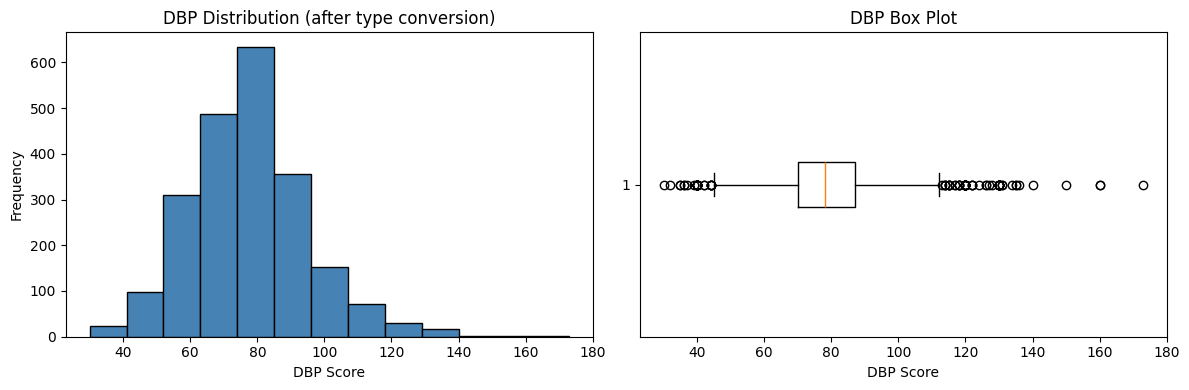

Plot saved as dbp_distribution.png


In [231]:
# Step 1: Visualising the column before we make any decisions on it
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw[COLUMN].dropna(), bins=13, edgecolor='black', color='steelblue')
axes[0].set_xlabel('DBP Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('DBP Distribution (after type conversion)')

axes[1].boxplot(df_raw[COLUMN].dropna(), vert=False)
axes[1].set_xlabel('DBP Score')
axes[1].set_title('DBP Box Plot')

plt.tight_layout()
plt.savefig('dbp_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as dbp_distribution.png")

In [232]:
# Step 2: Convert to numeric
df_raw[COLUMN] = pd.to_numeric(df_raw[COLUMN], errors='coerce')
print(f"After type conversion we have {df_raw[COLUMN].isnull().sum()} NaNs")
print(df_raw[COLUMN].describe())

After type conversion we have 22 NaNs
count    2183.000000
mean       77.479615
std        16.713289
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       173.000000
Name: DBP, dtype: float64


In [233]:
# Step 3: Range filter
invalid_dbp = df_raw[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX)]
print(f"Number of Out-of-range values: {len(invalid_dbp)}")

df_raw.loc[(df_raw[COLUMN] < VALID_MIN) | (df_raw[COLUMN] > VALID_MAX), COLUMN] = np.nan #changing all values out of range to NaN

Number of Out-of-range values: 3


In [234]:
invalid_dbp.head(10) #inspecting out of range values

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
375,395,77,1,15.0,201.0,173.0,182.33,100.0,37.5,18.0,21.0
951,981,63,0,15.0,220.0,160.0,180.00,100.0,36.3,20.0,40.0
1468,1510,61,0,15.0,125.0,160.0,185.00,86.0,39.0,20.0,21.0


In [235]:
# Step 4: Compare options for Imputing
print(f"Mean DBP: {df_raw[COLUMN].mean()}")
print(f"Median DBP: {df_raw[COLUMN].median()}")
print(f"Mode DBP: {df_raw[COLUMN].mode()}")

#Based on the data, no decimal values actually occur therefore making the mean a less accurate estimate of clinical results.
#The median is more realistic. Furthermore, the data is slightly skewed so a median better captures general trends.

Mean DBP: 77.36009174311927
Median DBP: 78.0
Mode DBP: 0    80.0
Name: DBP, dtype: float64


In [236]:
# Step 5: Imputing all the NaNs
print(f"Before cleaning:")
print(f"NaNs remaining: {df_raw[COLUMN].isnull().sum()}")

impute_value = df_raw[COLUMN].median()  #impute with median
df_raw[COLUMN] = df_raw[COLUMN].fillna(impute_value)

print(f"\nAfter cleaning:")
print(df_raw[COLUMN].describe())
print(f"NaNs remaining: {df_raw[COLUMN].isnull().sum()}")

Before cleaning:
NaNs remaining: 25

After cleaning:
count    2205.000000
mean       77.367347
std        16.316160
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       150.000000
Name: DBP, dtype: float64
NaNs remaining: 0


In [237]:
df_clean = df_raw.copy() #dataset with cleaned Gender, SBP, DBP and GCS columns.
df_clean.head(10)

,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0
5,6,42,1,15.0,100.0,60.0,73.33,99.0,37.0,20.0,21.0
6,7,75,0,15.0,120.0,80.0,93.33,99.0,37.0,25.0,21.0
7,8,25,1,15.0,100.0,50.0,66.67,85.0,37.0,25.0,21.0
8,9,67,0,15.0,110.0,70.0,83.33,78.0,37.0,16.0,21.0
9,11,82,0,15.0,153.0,82.0,105.67,130.0,37.0,19.0,21.0
